# 🪸 Stacking Ensemble Model — Coral Reef Bleaching Prediction

## Architecture
```
Layer 1 (Base Models)
  ├── 🌲 Random Forest   (Tree-based)
  ├── 🔷 SVM / SVR       (Linear / Kernel-based)
  └── 📍 KNN             (Distance-based)
        │
        ▼  (Predictions as new features)
Layer 2 (Meta-Learner)
  └── Logistic Regression (Classification) / Linear Regression (Regression)
```

| Dataset | Task | Target |
|---------|------|--------|
| **ROC** — Realistic Ocean Climate | Classification | Bleaching Severity (Low / Medium / High) |
| **GBE** — Global Bleaching Events | Regression | Percent Bleaching (0–100%) |

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Base Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# Meta-Learner
from sklearn.linear_model import LogisticRegression, LinearRegression

# Stacking
from sklearn.ensemble import StackingClassifier, StackingRegressor

# Metrics
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    mean_squared_error, r2_score, mean_absolute_error
)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## Part 1 — ROC Dataset (Classification)
**Target:** Bleaching Severity → 0=Low, 1=Medium, 2=High

In [2]:
df_roc = pd.read_csv('../data/cleaned_realistic_ocean_climate.csv')
print(f'Shape: {df_roc.shape}')
display(df_roc.head())
print('\nClass distribution:')
print(df_roc['Bleaching Severity'].value_counts().sort_index())

Shape: (500, 5)


,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity
0,20.0248,38.4931,29.47,8.107,0
1,-18.2988,147.7782,29.65,8.004,2
2,14.9768,-75.0233,28.86,7.947,2
3,-18.3152,147.6486,28.97,7.995,1
4,-0.8805,-90.9769,28.60,7.977,0



Class distribution:
Bleaching Severity
0    282
1    130
2     88
Name: count, dtype: int64


In [3]:
FEATURES_ROC = ['Latitude', 'Longitude', 'SST (°C)', 'pH Level']
TARGET_ROC   = 'Bleaching Severity'

X_roc = df_roc[FEATURES_ROC].values
y_roc = df_roc[TARGET_ROC].values

X_train_roc, X_test_roc, y_train_roc, y_test_roc = train_test_split(
    X_roc, y_roc, test_size=0.2, random_state=42, stratify=y_roc
)

scaler_roc = MinMaxScaler()
X_train_roc_sc = scaler_roc.fit_transform(X_train_roc)
X_test_roc_sc  = scaler_roc.transform(X_test_roc)

print(f'Train: {X_train_roc_sc.shape} | Test: {X_test_roc_sc.shape}')

Train: (400, 4) | Test: (100, 4)


### Define Stacking Classifier
- **Layer 1:** Random Forest + SVM (rbf kernel) + KNN
- **Layer 2:** Logistic Regression (meta-learner)

In [4]:
base_classifiers = [
    ('rf',  RandomForestClassifier(
                n_estimators=200, max_depth=5,
                min_samples_leaf=3, class_weight='balanced',
                random_state=42, n_jobs=-1)),
    ('svm', SVC(
                kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=True,
                random_state=42)),
    ('knn', KNeighborsClassifier(
                n_neighbors=7, metric='euclidean',
                weights='distance')),
]

meta_classifier = LogisticRegression(
    max_iter=500, class_weight='balanced', random_state=42
)

stacking_clf = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=meta_classifier,
    cv=5,
    passthrough=False,   # ส่งเฉพาะ predictions ของ base models ให้ meta-learner
    n_jobs=-1
)

print('✅ Stacking Classifier defined')
print('\nArchitecture:')
print('  Layer 1 (Base):')
for name, _ in base_classifiers:
    print(f'    [{name.upper()}]')
print('  Layer 2 (Meta): Logistic Regression')

✅ Stacking Classifier defined

Architecture:
  Layer 1 (Base):
    [RF]
    [SVM]
    [KNN]
  Layer 2 (Meta): Logistic Regression


In [5]:
print('🚀 Training Stacking Classifier (ROC)...')
stacking_clf.fit(X_train_roc_sc, y_train_roc)
print('✅ Training complete!')

🚀 Training Stacking Classifier (ROC)...
✅ Training complete!


In [6]:
y_pred_roc = stacking_clf.predict(X_test_roc_sc)

acc = accuracy_score(y_test_roc, y_pred_roc)
print(f'\n🎯 Stacking Classifier — Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(
    y_test_roc, y_pred_roc,
    target_names=['Low (0)', 'Medium (1)', 'High (2)']
))


🎯 Stacking Classifier — Test Accuracy: 0.4500 (45.00%)

Classification Report:
              precision    recall  f1-score   support

     Low (0)       0.63      0.55      0.59        56
  Medium (1)       0.29      0.27      0.28        26
    High (2)       0.26      0.39      0.31        18

    accuracy                           0.45       100
   macro avg       0.39      0.40      0.39       100
weighted avg       0.48      0.45      0.46       100



In [7]:
# --- Individual base model scores ---
print('📊 Individual Base Model Scores (5-fold CV on training set):')
for name, model in base_classifiers:
    scores = cross_val_score(model, X_train_roc_sc, y_train_roc, cv=5, scoring='accuracy', n_jobs=-1)
    print(f'  {name.upper():4s}: {scores.mean():.4f} ± {scores.std():.4f}')

stack_cv = cross_val_score(stacking_clf, X_train_roc_sc, y_train_roc, cv=5, scoring='accuracy', n_jobs=-1)
print(f'  STACK: {stack_cv.mean():.4f} ± {stack_cv.std():.4f}  ← Meta-Learner')

📊 Individual Base Model Scores (5-fold CV on training set):
  RF  : 0.3525 ± 0.0339
  SVM : 0.3150 ± 0.0382
  KNN : 0.4200 ± 0.0269
  STACK: 0.3100 ± 0.0700  ← Meta-Learner


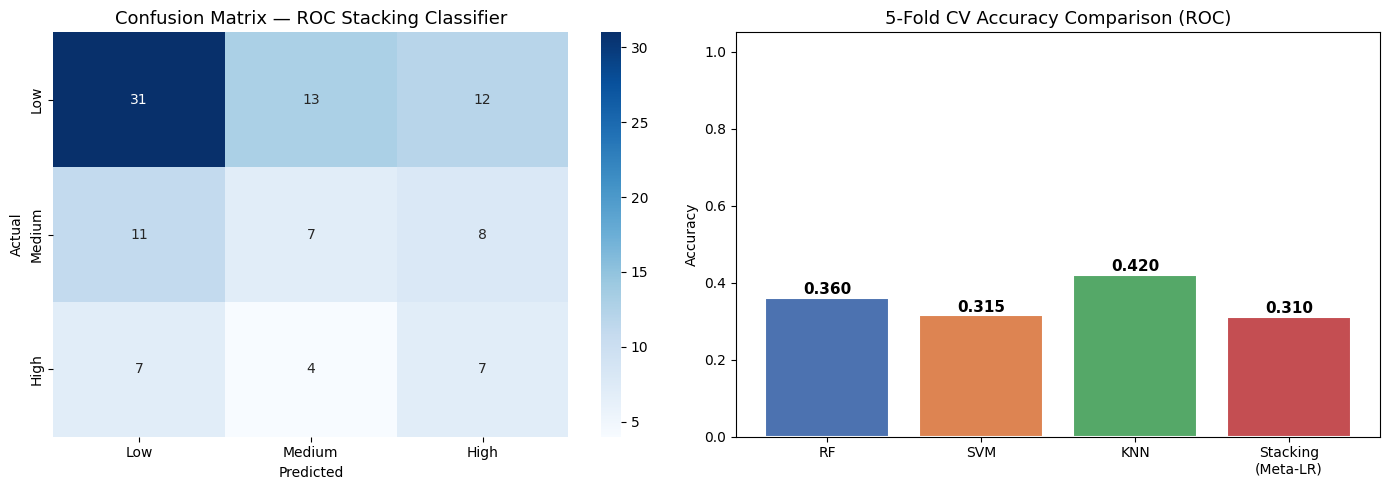

✅ Figure saved: models/stacking_roc_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_roc, y_pred_roc)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — ROC Stacking Classifier', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# CV Score Comparison
model_names = ['RF', 'SVM', 'KNN', 'Stacking\n(Meta-LR)']
model_fits  = [
    RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42),
    SVC(probability=True, class_weight='balanced', random_state=42),
    KNeighborsClassifier(n_neighbors=7, weights='distance'),
    stacking_clf
]
cv_means = []
for m in model_fits:
    s = cross_val_score(m, X_train_roc_sc, y_train_roc, cv=5, scoring='accuracy', n_jobs=-1)
    cv_means.append(s.mean())

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[1].bar(model_names, cv_means, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('5-Fold CV Accuracy Comparison (ROC)', fontsize=13)
axes[1].set_ylabel('Accuracy')
for bar, val in zip(bars, cv_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/stacking_roc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figure saved: models/stacking_roc_comparison.png')

---
## Part 2 — GBE Dataset (Regression)
**Target:** Percent_Bleaching (0–100%)

In [9]:
df_gbe = pd.read_csv('../data/cleaned_global_bleaching_events.csv')
print(f'Shape: {df_gbe.shape}')
display(df_gbe.head())
print(f'\nPercent_Bleaching stats:')
print(df_gbe['Percent_Bleaching'].describe())

Shape: (23131, 11)


,Depth_m,Distance_to_Shore,Turbidity,Windspeed,Cyclone_Frequency,Temperature_Maximum,SSTA,SSTA_Maximum,SSTA_DHW,TSA_DHW,Percent_Bleaching
0,10.00,8519.23,0.0287,8.0,49.90,304.69,-0.46,2.24,0.00,0.00,50.2
1,14.00,1431.62,0.0262,2.0,51.20,305.01,1.29,3.10,0.26,0.26,50.7
2,7.00,182.33,0.0429,8.0,61.52,304.14,0.04,2.83,0.00,0.00,50.9
3,9.02,313.13,0.0424,3.0,65.39,304.07,-0.07,2.47,0.00,0.00,50.9
4,12.50,792.00,0.0424,3.0,65.39,303.76,0.00,2.30,0.00,0.00,50.9



Percent_Bleaching stats:
count    23131.000000
mean        13.047154
std         22.974756
min          0.000000
25%          0.000000
50%          1.500000
75%         13.330000
max        100.000000
Name: Percent_Bleaching, dtype: float64


In [10]:
FEATURES_GBE = [
    'Depth_m', 'Distance_to_Shore', 'Turbidity',
    'Windspeed', 'Cyclone_Frequency',
    'Temperature_Maximum', 'SSTA_DHW'
]
TARGET_GBE = 'Percent_Bleaching'

X_gbe = df_gbe[FEATURES_GBE].values
y_gbe = df_gbe[TARGET_GBE].values

# Log transform — ลดความเบ้ของ target
y_gbe_log = np.log1p(y_gbe)

X_train_gbe, X_test_gbe, y_train_gbe_log, y_test_gbe_log = train_test_split(
    X_gbe, y_gbe_log, test_size=0.2, random_state=42
)
y_test_gbe_orig = np.expm1(y_test_gbe_log)

scaler_gbe = MinMaxScaler()
X_train_gbe_sc = scaler_gbe.fit_transform(X_train_gbe)
X_test_gbe_sc  = scaler_gbe.transform(X_test_gbe)

print(f'Train: {X_train_gbe_sc.shape} | Test: {X_test_gbe_sc.shape}')

Train: (18504, 7) | Test: (4627, 7)


### Define Stacking Regressor
- **Layer 1:** Random Forest + SVR + KNN Regressor
- **Layer 2:** Linear Regression (meta-learner)

In [11]:
base_regressors = [
    ('rf',  RandomForestRegressor(
                n_estimators=200, max_depth=10,
                min_samples_leaf=3, random_state=42, n_jobs=-1)),
    ('svr', SVR(
                kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')),
    ('knn', KNeighborsRegressor(
                n_neighbors=7, metric='euclidean',
                weights='distance')),
]

meta_regressor = LinearRegression()

stacking_reg = StackingRegressor(
    estimators=base_regressors,
    final_estimator=meta_regressor,
    cv=5,
    passthrough=False,
    n_jobs=-1
)

print('✅ Stacking Regressor defined')
print('\nArchitecture:')
print('  Layer 1 (Base):')
for name, _ in base_regressors:
    print(f'    [{name.upper()}]')
print('  Layer 2 (Meta): Linear Regression')

✅ Stacking Regressor defined

Architecture:
  Layer 1 (Base):
    [RF]
    [SVR]
    [KNN]
  Layer 2 (Meta): Linear Regression


In [12]:
print('🚀 Training Stacking Regressor (GBE)...')
stacking_reg.fit(X_train_gbe_sc, y_train_gbe_log)
print('✅ Training complete!')

🚀 Training Stacking Regressor (GBE)...
✅ Training complete!


In [13]:
y_pred_gbe_log  = stacking_reg.predict(X_test_gbe_sc)
y_pred_gbe_orig = np.clip(np.expm1(y_pred_gbe_log), 0, 100)

rmse = np.sqrt(mean_squared_error(y_test_gbe_orig, y_pred_gbe_orig))
mae  = mean_absolute_error(y_test_gbe_orig, y_pred_gbe_orig)
r2   = r2_score(y_test_gbe_orig, y_pred_gbe_orig)

print(f'\n📊 Stacking Regressor — GBE Test Metrics:')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  R²   : {r2:.4f}')


📊 Stacking Regressor — GBE Test Metrics:
  RMSE : 18.9111
  MAE  : 9.4071
  R²   : 0.2955


In [14]:
# --- Individual base model scores ---
print('📊 Individual Base Model R² (5-fold CV on training set):')
for name, model in base_regressors:
    scores = cross_val_score(
        model, X_train_gbe_sc, y_train_gbe_log,
        cv=5, scoring='r2', n_jobs=-1
    )
    print(f'  {name.upper():4s}: {scores.mean():.4f} ± {scores.std():.4f}')

stack_cv = cross_val_score(
    stacking_reg, X_train_gbe_sc, y_train_gbe_log,
    cv=5, scoring='r2', n_jobs=-1
)
print(f'  STACK: {stack_cv.mean():.4f} ± {stack_cv.std():.4f}  ← Meta-Learner')

📊 Individual Base Model R² (5-fold CV on training set):
  RF  : 0.4753 ± 0.0081
  SVR : 0.2146 ± 0.0150
  KNN : 0.4300 ± 0.0116
  STACK: 0.5174 ± 0.0087  ← Meta-Learner


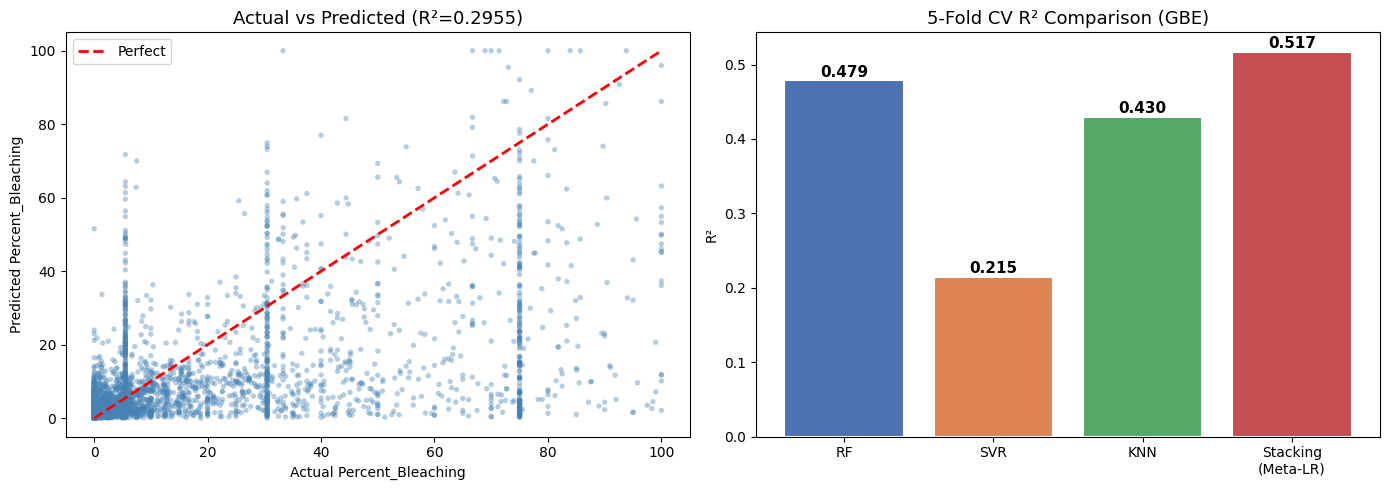

✅ Figure saved: models/stacking_gbe_comparison.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_gbe_orig, y_pred_gbe_orig,
                alpha=0.4, s=15, color='steelblue', edgecolors='none')
max_val = max(y_test_gbe_orig.max(), y_pred_gbe_orig.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual Percent_Bleaching')
axes[0].set_ylabel('Predicted Percent_Bleaching')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.4f})', fontsize=13)
axes[0].legend()

# CV R² Comparison
model_names_reg = ['RF', 'SVR', 'KNN', 'Stacking\n(Meta-LR)']
model_fits_reg  = [
    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    SVR(kernel='rbf'),
    KNeighborsRegressor(n_neighbors=7, weights='distance'),
    stacking_reg
]
cv_r2_means = []
for m in model_fits_reg:
    s = cross_val_score(m, X_train_gbe_sc, y_train_gbe_log, cv=5, scoring='r2', n_jobs=-1)
    cv_r2_means.append(s.mean())

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = axes[1].bar(model_names_reg, cv_r2_means, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('5-Fold CV R² Comparison (GBE)', fontsize=13)
axes[1].set_ylabel('R²')
for bar, val in zip(bars, cv_r2_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/stacking_gbe_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figure saved: models/stacking_gbe_comparison.png')

---
## Part 3 — Save Models

In [16]:
# Save Stacking models
joblib.dump(stacking_clf, '../models/stacking_classifier_ROC.pkl')
joblib.dump(scaler_roc,   '../models/scaler_stacking_ROC.pkl')

joblib.dump(stacking_reg, '../models/stacking_regressor_GBE.pkl')
joblib.dump(scaler_gbe,   '../models/scaler_stacking_GBE.pkl')

print('✅ Models saved:')
print('  models/stacking_classifier_ROC.pkl')
print('  models/scaler_stacking_ROC.pkl')
print('  models/stacking_regressor_GBE.pkl')
print('  models/scaler_stacking_GBE.pkl')

✅ Models saved:
  models/stacking_classifier_ROC.pkl
  models/scaler_stacking_ROC.pkl
  models/stacking_regressor_GBE.pkl
  models/scaler_stacking_GBE.pkl


---
## Summary

| | ROC (Classification) | GBE (Regression) |
|---|---|---|
| **Base Model 1** | Random Forest | Random Forest |
| **Base Model 2** | SVM (RBF kernel) | SVR (RBF kernel) |
| **Base Model 3** | KNN (distance-weighted) | KNN Regressor (distance-weighted) |
| **Meta-Learner** | Logistic Regression | Linear Regression |
| **CV Folds** | 5 | 5 |
| **Target** | Severity class (0/1/2) | Percent Bleaching (0–100%) |